# Descripción del proyecto

Los clientes de Beta Bank se están yendo, cada mes, poco a poco. Los banqueros descubrieron que es más barato salvar a los clientes existentes que atraer nuevos.

Necesitamos predecir si un cliente dejará el banco pronto. Tú tienes los datos sobre el comportamiento pasado de los clientes y la terminación de contratos con el banco.

Crea un modelo con el máximo valor F1 posible. Para aprobar la revisión, necesitas un valor F1 de al menos 0.59. Verifica F1 para el conjunto de prueba. 

Además, debes medir la métrica AUC-ROC y compararla con el valor F1.

In [393]:
# Librerías
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
import matplotlib.pyplot as plt
from sklearn.utils import resample, shuffle
from sklearn.ensemble import RandomForestClassifier

# Paso 1. Preparación de los datos

## Lectura y reconocimiento de los datos

In [394]:
df = pd.read_csv('datasets/Churn.csv')

In [395]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB
None


In [396]:
print(df.head())

   RowNumber  CustomerId   Surname  ...  IsActiveMember EstimatedSalary Exited
0          1    15634602  Hargrave  ...               1       101348.88      1
1          2    15647311      Hill  ...               1       112542.58      0
2          3    15619304      Onio  ...               0       113931.57      1
3          4    15701354      Boni  ...               0        93826.63      0
4          5    15737888  Mitchell  ...               1        79084.10      0

[5 rows x 14 columns]


## Nulls

In [397]:
df['Tenure'] = df['Tenure'].fillna(0)

Se asigno el valor 0 a los nulls de la columna Tenure ya que los modelos podrían causar problemas. Y 0 sería un buen indicador de que el cliente aun no tiene depósito a plazo fijo.

## Eliminar columnas

In [398]:

columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns_to_drop, axis=1)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  float64
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 859.5+ KB
None


Se elimino las columnas "RowNumber", "CustomerId", "Surname", ya que tiene que ver con los usuarios y el modelo podría preferir algunos apellidos.

## Codificación One-Hot

In [399]:
# dummies
categorical_cols = ['Gender', 'Geography']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(df.info())
print()
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  float64
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Gender_Male        10000 non-null  bool   
 10  Geography_Germany  10000 non-null  bool   
 11  Geography_Spain    10000 non-null  bool   
dtypes: bool(3), float64(3), int64(6)
memory usage: 732.6 KB
None

   CreditScore  Age  Tenure  ...  Gender_Male  Geography_Germany  Geography_Spain
0          619   42     2.0  ...        False              False       

Se transformo la característica categorica Gender y Geography a variables dummy, con la ayuda de One-Hot Enconding.
Tambíen definio el pararametro drop_first en True para eliminar la primera columna para evitarlos confundir al modelo con la alta correlación.

## Separación en conjuntos de entrenamiento, validación y prueba

In [400]:
# Separación de las características y el objetivo
features = df.drop('Exited', axis=1)
target = df['Exited']

print(f'Características: {features.shape}')
print(f'Objetivo: {target.shape}')

Características: (10000, 11)
Objetivo: (10000,)


In [401]:
# Conjunto de entrenamiento, validación y prueba
features_train, features_res, target_train, target_res = train_test_split(
    features,
    target,
    random_state=12345,
    test_size=0.40
)

features_valid, features_test, target_valid, target_test = train_test_split(
    features_res,
    target_res,
    random_state=12345,
    test_size=0.50
)

print(f'Tamaño del conjunto de entrenamiento {features_train.shape}')
print(f'Tamaño del conjunto de validación {features_valid.shape}')
print(f'Tamaño del conjunto de prueba {features_test.shape}')

Tamaño del conjunto de entrenamiento (6000, 11)
Tamaño del conjunto de validación (2000, 11)
Tamaño del conjunto de prueba (2000, 11)


1. Se separo las características y el objetivo
2. Se asigno 60% de las observaciones para el conjunto de entrenamiento y 20% tanto para el conjunto de validación como el de prueba.

## Escalado de características

In [402]:
numeric = ['CreditScore', 'Age', 'Balance', 'NumOfProducts', 'EstimatedSalary']
scaler = StandardScaler()
scaler.fit(features_train[numeric])
print('Entrenado')

Entrenado


In [403]:
features_train[numeric] = scaler.transform(features_train[numeric])
features_valid[numeric] = scaler.transform(features_valid[numeric])
features_test[numeric] = scaler.transform(features_test[numeric])

print(features_train.head())

      CreditScore       Age  ...  Geography_Germany  Geography_Spain
7479    -0.886751 -0.373192  ...              False             True
3411     0.608663 -0.183385  ...              False            False
6027     2.052152  0.480939  ...               True            False
1247    -1.457915 -1.417129  ...              False            False
3716     0.130961 -1.132419  ...               True            False

[5 rows x 11 columns]


# Paso 2. Examinando el equilibrio de clases

## Examinar la clase objetivo

In [404]:
print('Distribución de clases')
print(df['Exited'].value_counts())

Distribución de clases
Exited
0    7963
1    2037
Name: count, dtype: int64


In [405]:
print('Porcentajes')
print(df['Exited'].value_counts(normalize=True) * 100)

Porcentajes
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


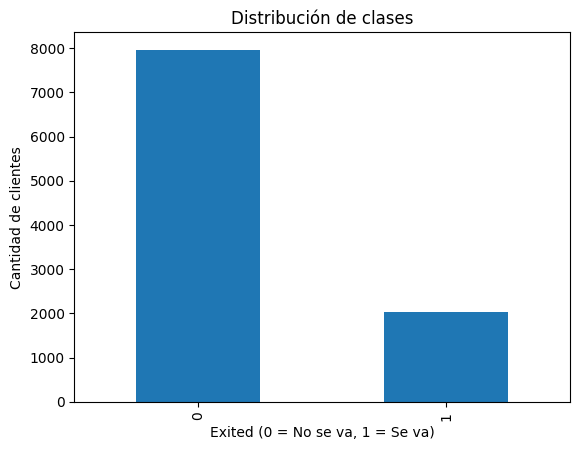

In [406]:
df['Exited'].value_counts().plot(kind='bar')
plt.title('Distribución de clases')
plt.xlabel('Exited (0 = No se va, 1 = Se va)')
plt.ylabel('Cantidad de clientes')
plt.show()

Se puede observar que realmente existe una diferencia en las clases objetivo. 80% de los clientes no dejan los servicios mientras que el 20% si deja los servicios.

## Entrena el modelo sin tener en cuenta el desequilibrio

In [407]:
model = LogisticRegression(solver='liblinear', random_state=12345)
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)

print(f1_score(target_valid, predicted_valid))

0.33389544688026984


In [408]:
print(f'Valores 1: {(target_train == 0).sum()}')
print(f'Valores 0: {(target_train == 1).sum()}')

Valores 1: 4804
Valores 0: 1196


El modelo entrenado sin resolver el desequilibrio nos da un valor f1 de 0.14, muy retirado de la necesidad del proyecto.

# Paso 3. Mejorar la calidad del modelo

## Enfoque 1. (ajuste del peso de las clases) para resolver el desequilibrio de clases

In [409]:
model = LogisticRegression(solver='liblinear', random_state=12345, class_weight='balanced')
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)

print(f'F1: {f1_score(target_valid, predicted_valid)}')

F1: 0.4888888888888889


Enfoque: ajustando del peso de clases.

## Enfoque 2 (upsampling) para resolver el desequilibrio de clases

In [410]:
def upsample(features, target):
    features_ones_minority = features[target == 1]
    features_zeros_majority = features[target == 0]
    target_ones_minority = target[target == 1]
    target_zeros_majority = target[target == 0]

    features_ones_upsampled, target_ones_upsampled = resample(
        features_ones_minority,
        target_ones_minority,
        replace=True,
        n_samples=len(features_zeros_majority),
        random_state=12345
    )

    features_upsampled = pd.concat([features_ones_upsampled, features_zeros_majority])
    target_upsampled = pd.concat([target_ones_upsampled, target_zeros_majority])

    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345
    )

    return features_upsampled, target_upsampled

In [411]:
features_train_upsampled, target_train_upsampled = upsample(
    features_train, target_train
)
print('Antes del sobremuestreo')
print(target_train.value_counts())
print()
print('Después del sobremuestreo')
print(target_train_upsampled.value_counts())

Antes del sobremuestreo
Exited
0    4804
1    1196
Name: count, dtype: int64

Después del sobremuestreo
Exited
0    4804
1    4804
Name: count, dtype: int64


In [412]:
model = LogisticRegression(solver='liblinear', random_state=12345)
model.fit(features_train_upsampled, target_train_upsampled)
predicted_valid = model.predict(features_valid)

print(f'F1: {f1_score(target_valid, predicted_valid)}')

F1: 0.48625429553264604


## Enfoque 3 (ajuste de umbral) para resolver el desequilibrio de clases

In [413]:
model = LogisticRegression(solver='liblinear', random_state=12345, class_weight='balanced')
model.fit(features_train_upsampled, target_train_upsampled)
probabilities_valid = model.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]

for threshold in np.arange(0, 1, 0.1):
    predicted_valid = probabilities_one_valid > threshold
    precision = precision_score(target_valid, predicted_valid)
    recall = recall_score(target_valid, predicted_valid)
    print(
        'Threshold = {:.2f} | Precision = {:.3f}, Recall = {:.3f}, F1 = {:.3f}'.format(
            threshold, precision, recall, f1_score(target_valid, predicted_valid)
        )
    )

Threshold = 0.00 | Precision = 0.209, Recall = 1.000, F1 = 0.346
Threshold = 0.10 | Precision = 0.216, Recall = 1.000, F1 = 0.355
Threshold = 0.20 | Precision = 0.242, Recall = 0.969, F1 = 0.388
Threshold = 0.30 | Precision = 0.276, Recall = 0.904, F1 = 0.422
Threshold = 0.40 | Precision = 0.329, Recall = 0.818, F1 = 0.469
Threshold = 0.50 | Precision = 0.379, Recall = 0.677, F1 = 0.486
Threshold = 0.60 | Precision = 0.442, Recall = 0.567, F1 = 0.497
Threshold = 0.70 | Precision = 0.486, Recall = 0.378, F1 = 0.425
Threshold = 0.80 | Precision = 0.574, Recall = 0.242, F1 = 0.340
Threshold = 0.90 | Precision = 0.538, Recall = 0.050, F1 = 0.092


## Bosque aleatorio

In [414]:
for est in range(10, 51, 10):
    for depth in range(1, 6):
        model = RandomForestClassifier(max_depth=depth, n_estimators=est, random_state=12345, class_weight='balanced')
        model.fit(features_train_upsampled, target_train_upsampled)
        predicted_valid = model.predict(features_valid)
        print(f'F1: {f1_score(target_valid, predicted_valid)}, depth: {depth}, n_estimators: {est}')

F1: 0.5264116575591985, depth: 1, n_estimators: 10
F1: 0.5617342130065975, depth: 2, n_estimators: 10
F1: 0.5655664585191793, depth: 3, n_estimators: 10
F1: 0.5958291956305859, depth: 4, n_estimators: 10
F1: 0.6064769381746811, depth: 5, n_estimators: 10
F1: 0.5384615384615384, depth: 1, n_estimators: 20
F1: 0.540120793787748, depth: 2, n_estimators: 20
F1: 0.5610619469026549, depth: 3, n_estimators: 20
F1: 0.5958291956305859, depth: 4, n_estimators: 20
F1: 0.6025768087215064, depth: 5, n_estimators: 20
F1: 0.5186412593206297, depth: 1, n_estimators: 30
F1: 0.5487804878048781, depth: 2, n_estimators: 30
F1: 0.5484429065743944, depth: 3, n_estimators: 30
F1: 0.588124410933082, depth: 4, n_estimators: 30
F1: 0.5909528392685275, depth: 5, n_estimators: 30
F1: 0.5376344086021505, depth: 1, n_estimators: 40
F1: 0.5660714285714286, depth: 2, n_estimators: 40
F1: 0.5755656108597285, depth: 3, n_estimators: 40
F1: 0.594541910331384, depth: 4, n_estimators: 40
F1: 0.6090373280943026, depth: 5, 

In [415]:
model = RandomForestClassifier(max_depth=5, n_estimators=40, random_state=12345, class_weight='balanced')
model.fit(features_train_upsampled, target_train_upsampled)

probabilities_valid = model.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]

for threshold in np.arange(0.1, 0.6, 0.05):
    predicted_valid = probabilities_one_valid > threshold
    print(f'F1: {f1_score(target_valid, predicted_valid)}, threshold = {threshold:.2f}')

F1: 0.3457402812241522, threshold = 0.10
F1: 0.35368956743002544, threshold = 0.15
F1: 0.3767186067827681, threshold = 0.20
F1: 0.41988365943945005, threshold = 0.25
F1: 0.4440538957234915, threshold = 0.30
F1: 0.48764629388816644, threshold = 0.35
F1: 0.5327313769751693, threshold = 0.40
F1: 0.5677966101694916, threshold = 0.45
F1: 0.6090373280943026, threshold = 0.50
F1: 0.6297117516629712, threshold = 0.55


Se entrenaron modelos de regresión logística aplicando cada vez más enfoques para resolver el desequilibrio de clases, pero no se pudo obtener el f1 deseado para este caso, así es que se se probó con un modelo de bosque aleatorio con el cual si se alcanzaron los objetivos del proyecto, estas son los enfoques y configuraciones que se utilizaron durante el entrenamiento:

Enfoque para resolver el desequilibrio de clases
1. Ajuste del peso de clases
2. Sobremuestreo
3. Se puedo mejorar aun más buscando el mejor umbral

Hiperparametros
- n_estimators = 40
- max_depth = 5

# Paso 4. Prueba final

In [416]:
model = RandomForestClassifier(max_depth=5, n_estimators=40, random_state=12345, class_weight='balanced')
model.fit(features_train_upsampled, target_train_upsampled)
print('Entrenado')

Entrenado


In [417]:
# Probando con el mejor umbral encontrado
best_threshold = 0.55
probabilities_test = model.predict_proba(features_test)
probabilities_one_test = probabilities_test[:, 1]
predicted_test = probabilities_one_test > best_threshold

print(f'F1: {f1_score(target_test, predicted_test)}')

F1: 0.5909592061742006


In [418]:
# Probando únicamente con el enfoque de mejora de ajuste de pesos y sobremuestreo
predicted_test = model.predict(features_test)

print(f'F1: {f1_score(target_test, predicted_test)}')

F1: 0.597478176527643


In [419]:
# AUC-ROC
probability_test = model.predict_proba(features_test)
probability_one_test = probability_test[:, 1]
auc_roc = roc_auc_score(target_test, probability_one_test)

print(f'AUC-ROC: {auc_roc}')

AUC-ROC: 0.8430744253610185


# Conclusión final

- Se obtuvo un F1 de 0.59 en el conjunto de prueba, cumpliendo el requisito mínimo del proyecto.
- Se obtuvo un AUC-ROC de 0.84, lo que indica que el modelo tiene muy buena capacidad para distinguir entre clientes que se van y los que se quedan.
- El AUC-ROC significativamente mayor que el F1 sugiere que el modelo discrimina bien en todos los umbrales, pero ajustar el umbral no mejoró el F1 en este caso, ya que el modelo ya estaba bien calibrado con los enfoques: ajustes del peso de clases y sobremuestreo.
- El modelo final fue un Bosque Aleatorio con max_depth=5, n_estimators=40, class_weight='balanced' y sobremuestreo de la clase minoritaria.
- Dado que retener clientes es más barato que atraer nuevos, este modelo permite al banco identificar clientes en riesgo con suficiente precisión para tomar acciones preventivas.